# 02 · 용접기 데이터 탐색

## EDA 계획

1. Excel 세 시트와 scaled CSV의 역할·스키마·결측·중복을 확인합니다.
2. 원본 공정값의 분포, 문서에 기재된 수집 범위 이탈, 스케일링 결과를 비교합니다.
3. 설비·품목·날짜별 공정 변동과 변수 간 관계를 살펴봅니다.
4. 불량 결과의 집계 단위와 결합 가능성을 확인하고 집계 수준에서만 시각화합니다.
5. 품질 예측/이상 탐지 주제의 가능성과 검증에 필요한 추가 정보를 정리합니다.


원본 데이터는 수정하지 않습니다. 위에서부터 실행하세요. 프로젝트 `.venv` 커널과 `notebooks/requirements.txt`의 패키지를 사용합니다. 수치와 도표는 전체 데이터를 기준으로 하며 표본·표시 범위를 제한하면 해당 셀에 명시합니다. 탐색 결과는 모델 성능이나 인과 효과를 의미하지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir())
pd.set_option('display.max_columns', 30)
fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = [next((f for f in ['Malgun Gothic','AppleGothic','NanumGothic'] if f in fonts), 'DejaVu Sans'), 'DejaVu Sans']
plt.rcParams.update({'axes.unicode_minus':False, 'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})

def quality(df, exclude=()):
    x = df.drop(columns=list(exclude), errors='ignore')
    out = pd.DataFrame({'dtype':x.dtypes.astype(str), 'missing':x.isna().sum(),
                        'missing_pct':x.isna().mean()*100, 'unique':x.nunique()})
    print(f'행 {len(df):,} / 열 {len(df.columns)} / 제외 열을 뺀 중복 {x.duplicated().sum():,}')
    display(out)
    return out

def corr_plot(df, cols, title):
    corr = df[cols].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7,len(cols)*.65), max(5,len(cols)*.6)))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)),cols,rotation=70,ha='right')
    ax.set_yticks(range(len(cols)),cols); ax.set_title(title)
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def hist_grid(df, cols, title):
    fig, axes = plt.subplots(int(np.ceil(len(cols)/3)),3,figsize=(15,3.4*int(np.ceil(len(cols)/3))),squeeze=False)
    for ax,c in zip(axes.flat,cols):
        ax.hist(df[c].replace([np.inf,-np.inf],np.nan).dropna(),bins=40,color='#2563eb',alpha=.8)
        ax.set_title(c,fontsize=10); ax.set_ylabel('행 수')
    for ax in list(axes.flat)[len(cols):]: ax.set_visible(False)
    fig.suptitle(title); plt.tight_layout(); plt.show()

DATA = next((ROOT / 'data').glob('2.*'))

## 1. 원본과 스케일링 파일
`data set` 시트의 설명·단위를 기준으로 해석합니다. `result.idx`를 개별 용접 기록 ID라고 가정하지 않습니다.

,sheet,rows,columns
0,Raw data,11939,10
1,result,23,7
2,data set,10,3


,Data,항목 설명,수집 범위
0,idx,생산순번,-
1,Machine_Name,생산설비,-
2,Item No,생산품목,-
3,working time,작업시간,-
4,Thickness 1(mm),소재 두께 1,0.3-2.3
5,Thickness 2(mm),소재 두께 2,0.3-2.3
6,weld force(bar),용접 가압력,1.00~12.00
7,weld current(kA),전류,12.00~18.00
8,weld Voltage(v),전압,1.50~3.50
9,weld time(ms),통전시간,30~120


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6
0,1,Spot-01,65235-25800,2020-03-24,2,1,파임불량
1,2,Spot-01,65235-25800,2020-03-24,1,2,용접부족
2,3,Spot-01,65235-25800,2020-03-24,1,3,크랙발생
3,4,Spot-01,65235-25800,2020-03-25,3,1,NaN
4,5,Spot-01,65235-25800,2020-03-25,2,2,NaN


행 11,939 / 열 10 / 제외 열을 뺀 중복 5,081


,dtype,missing,missing_pct,unique
Machine_Name,str,0,0.0,1
Item No,str,0,0.0,1
working time,datetime64[us],0,0.0,9
Thickness 1(mm),float64,0,0.0,1
Thickness 2(mm),float64,0,0.0,1
weld force(bar),float64,0,0.0,177
weld current(kA),float64,0,0.0,43
weld Voltage(v),float64,0,0.0,113
weld time(ms),float64,0,0.0,8


행 11,939 / 열 5 / 제외 열을 뺀 중복 10,665


,dtype,missing,missing_pct,unique
용접 가압력,float64,18,0.150766,212
전류,float64,15,0.125639,84
전압,float64,15,0.125639,48
통전시간,float64,23,0.192646,39


행 23 / 열 7 / 제외 열을 뺀 중복 0


,dtype,missing,missing_pct,unique
Machine_Name,str,0,0.0,1
Item No,str,0,0.0,1
working time,datetime64[us],0,0.0,8
defect,int64,0,0.0,4
defect type,int64,0,0.0,3


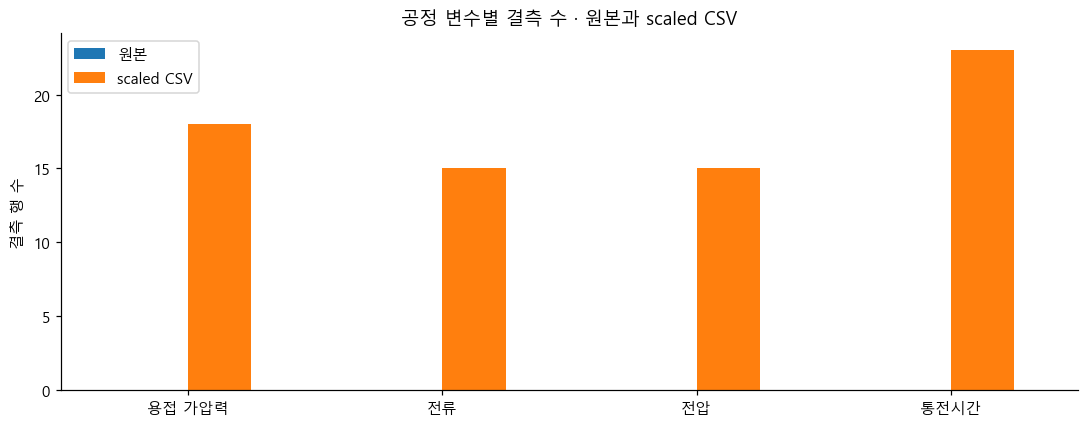

In [2]:
book = next(DATA.rglob('*.xlsx'))
sheets = pd.read_excel(book, sheet_name=None)
raw, result, dictionary = sheets['Raw data'], sheets['result'], sheets['data set']
scaled = pd.read_csv(next(DATA.rglob('scaled_data.csv')), encoding='cp949')
display(pd.DataFrame([{'sheet':k,'rows':len(v),'columns':len(v.columns)} for k,v in sheets.items()]))
display(dictionary); display(raw.head()); display(result.head())
qraw=quality(raw, ['idx']); qscaled=quality(scaled, ['Unnamed: 0']); quality(result,['idx','Unnamed: 6'])
process=['weld force(bar)','weld current(kA)','weld Voltage(v)','weld time(ms)']
fig, ax=plt.subplots(figsize=(10,4))
missing_compare=pd.DataFrame({'원본':raw[process].isna().sum().to_numpy(),
                              'scaled CSV':scaled[['용접 가압력','전류','전압','통전시간']].isna().sum().to_numpy()},
                             index=['용접 가압력','전류','전압','통전시간'])
missing_compare.plot.bar(ax=ax,title='공정 변수별 결측 수 · 원본과 scaled CSV',rot=0)
ax.set_ylabel('결측 행 수');plt.tight_layout();plt.show()

## 2. 원본 분포와 수집 범위
범위 이탈은 설명 시트의 수집 범위를 벗어난 값입니다. 품질 불량의 정답으로 간주하거나 자동 제거하지 않습니다. 전체 범위와 중앙 98%를 함께 표시해 극단값에 가려진 분포를 확인합니다.

,count,mean,std,min,25%,50%,75%,max
Thickness 1(mm),11939.0,0.700000,1.110270e-16,0.700,0.700,0.700,0.700,0.700
Thickness 2(mm),11939.0,0.700000,1.110270e-16,0.700,0.700,0.700,0.700,0.700
weld force(bar),11939.0,2.787925,1.455966e+00,1.740,2.310,2.340,2.370,10.540
weld current(kA),11939.0,14.711208,9.900036e-02,14.520,14.610,14.730,14.750,15.070
weld Voltage(v),11939.0,2.704223,2.469965e-02,2.464,2.699,2.702,2.706,2.861
weld time(ms),11939.0,71.724123,6.320494e-01,70.000,71.000,72.000,72.000,73.000


,feature,low,high,outside,missing
0,Thickness 1(mm),0.3,2.3,0,0
1,Thickness 2(mm),0.3,2.3,0,0
2,weld force(bar),1.0,12.0,0,0
3,weld current(kA),12.0,18.0,0,0
4,weld Voltage(v),1.5,3.5,0,0
5,weld time(ms),30.0,120.0,0,0


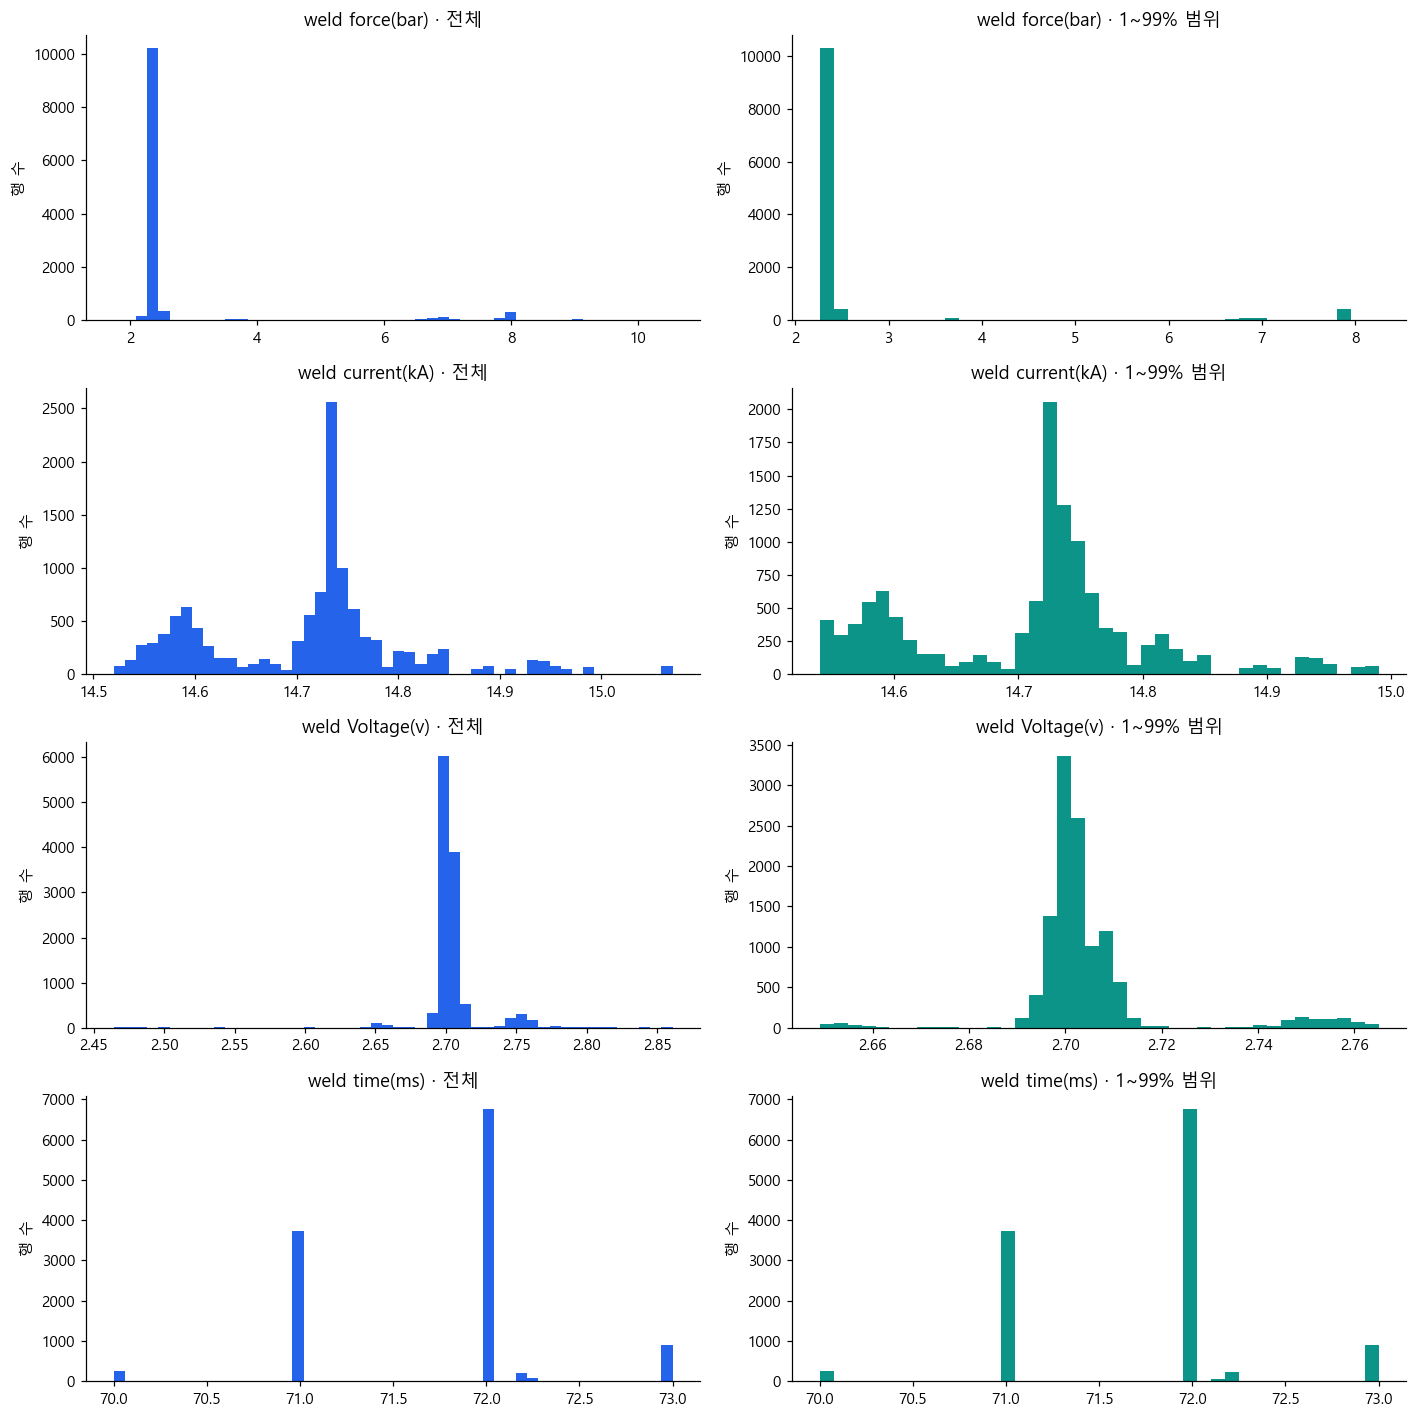

In [3]:
ranges={'Thickness 1(mm)':(.3,2.3),'Thickness 2(mm)':(.3,2.3),
        'weld force(bar)':(1,12),'weld current(kA)':(12,18),'weld Voltage(v)':(1.5,3.5),'weld time(ms)':(30,120)}
display(raw[list(ranges)].describe().T)
range_audit=pd.DataFrame([{'feature':c,'low':lo,'high':hi,'outside':int((raw[c].notna() & ~raw[c].between(lo,hi)).sum()),'missing':int(raw[c].isna().sum())} for c,(lo,hi) in ranges.items()])
display(range_audit)
fig,axes=plt.subplots(4,2,figsize=(13,13))
for row,c in enumerate(process):
    v=raw[c].dropna(); lo,hi=v.quantile([.01,.99])
    axes[row,0].hist(v,bins=50,color='#2563eb');axes[row,0].set_title(c+' · 전체')
    axes[row,1].hist(v[v.between(lo,hi)],bins=40,color='#0d9488');axes[row,1].set_title(c+' · 1~99% 범위')
    for ax in axes[row]: ax.set_ylabel('행 수')
plt.tight_layout();plt.show()

## 3. 스케일링 파일의 대응 여부
원본의 min-max 변환과 CSV를 행별·정렬값별로 대조합니다. 일치하지 않으면 파일 간 순서/전처리 차이를 확인해야 하며, 원본 메타데이터나 불량 집계를 scaled CSV에 행 순서로 붙이지 않습니다.

,feature,row_match_pct,sorted_values_match,raw_missing,scaled_missing
0,용접 가압력,0.016752,False,0,18
1,전류,0.058631,False,0,15
2,전압,0.016752,False,0,15
3,통전시간,0.175894,False,0,23


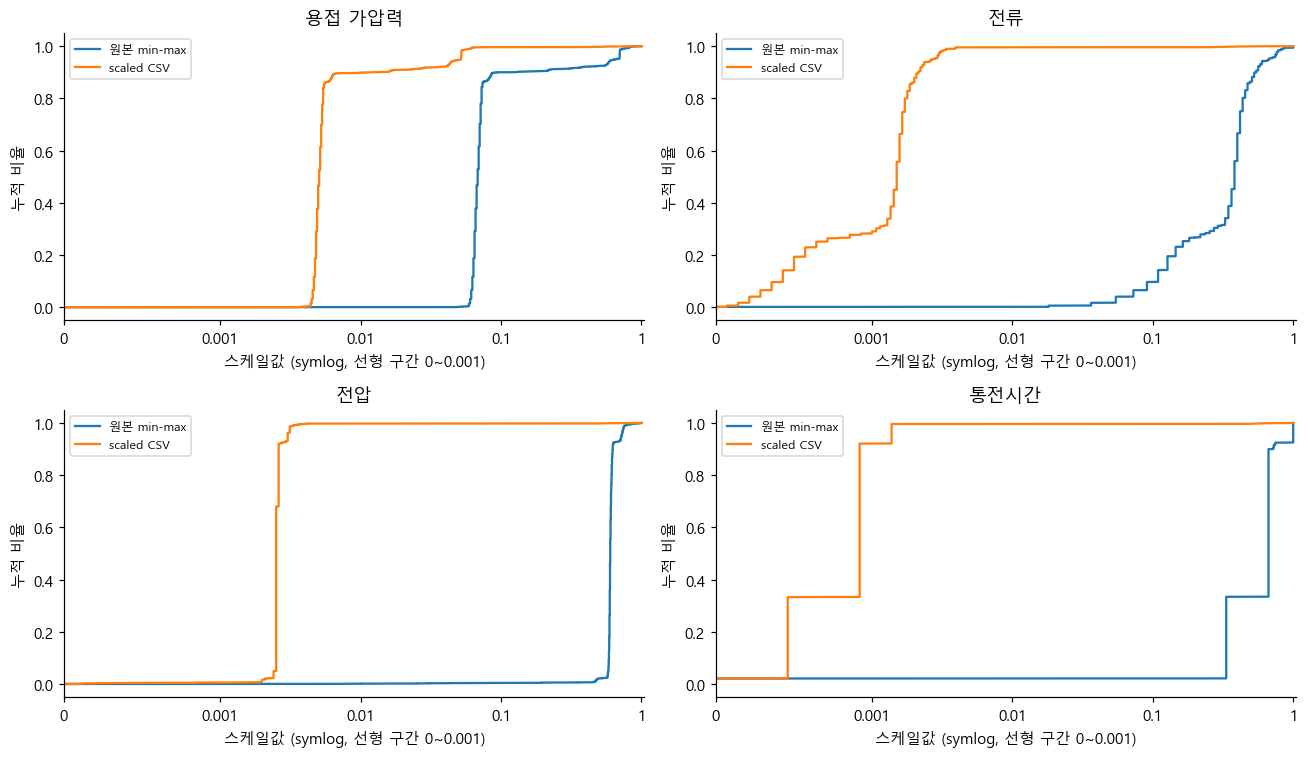

In [4]:
mapping=dict(zip(process,['용접 가압력','전류','전압','통전시간']))
audit=[]
fig,axes=plt.subplots(2,2,figsize=(12,7))
for ax,(a,b) in zip(axes.flat,mapping.items()):
    mm=(raw[a]-raw[a].min())/(raw[a].max()-raw[a].min())
    same_len=len(mm)==len(scaled)
    match=np.isclose(mm.to_numpy(),scaled[b].to_numpy(),equal_nan=True) if same_len else np.array([False])
    left,right=np.sort(mm.dropna()),np.sort(scaled[b].dropna())
    audit.append({'feature':b,'row_match_pct':match.mean()*100 if same_len else np.nan,
                  'sorted_values_match':len(left)==len(right) and np.allclose(left,right),
                  'raw_missing':raw[a].isna().sum(),'scaled_missing':scaled[b].isna().sum()})
    for values,label in [(mm,'원본 min-max'),(scaled[b],'scaled CSV')]:
        v=np.sort(values.dropna()); ax.plot(v,np.arange(1,len(v)+1)/len(v),label=label)
    ax.set_xscale('symlog',linthresh=.001)
    ax.set_xticks([0,.001,.01,.1,1],['0','0.001','0.01','0.1','1'])
    ax.set_xlim(0,1.05)
    ax.set(title=b,xlabel='스케일값 (symlog, 선형 구간 0~0.001)',ylabel='누적 비율');ax.legend(fontsize=8)
display(pd.DataFrame(audit));plt.tight_layout();plt.show()

## 4. 날짜별 공정 변동과 변수 관계
작업시간이 날짜 단위이므로 초 단위 시계열로 해석하지 않습니다. idx는 생산순번이며 모델 입력에서 제외할 후보입니다.

records
Machine_Name Item No     working time         
Spot-01      65235-25800 2020-03-24       1200
                         2020-03-25       1352
                         2020-03-26       1000
                         2020-03-27       1648
                         2020-03-30       1470
                         2020-03-31       1800
                         2020-04-02       2000
                         2020-04-03        800
                         2020-04-07        669

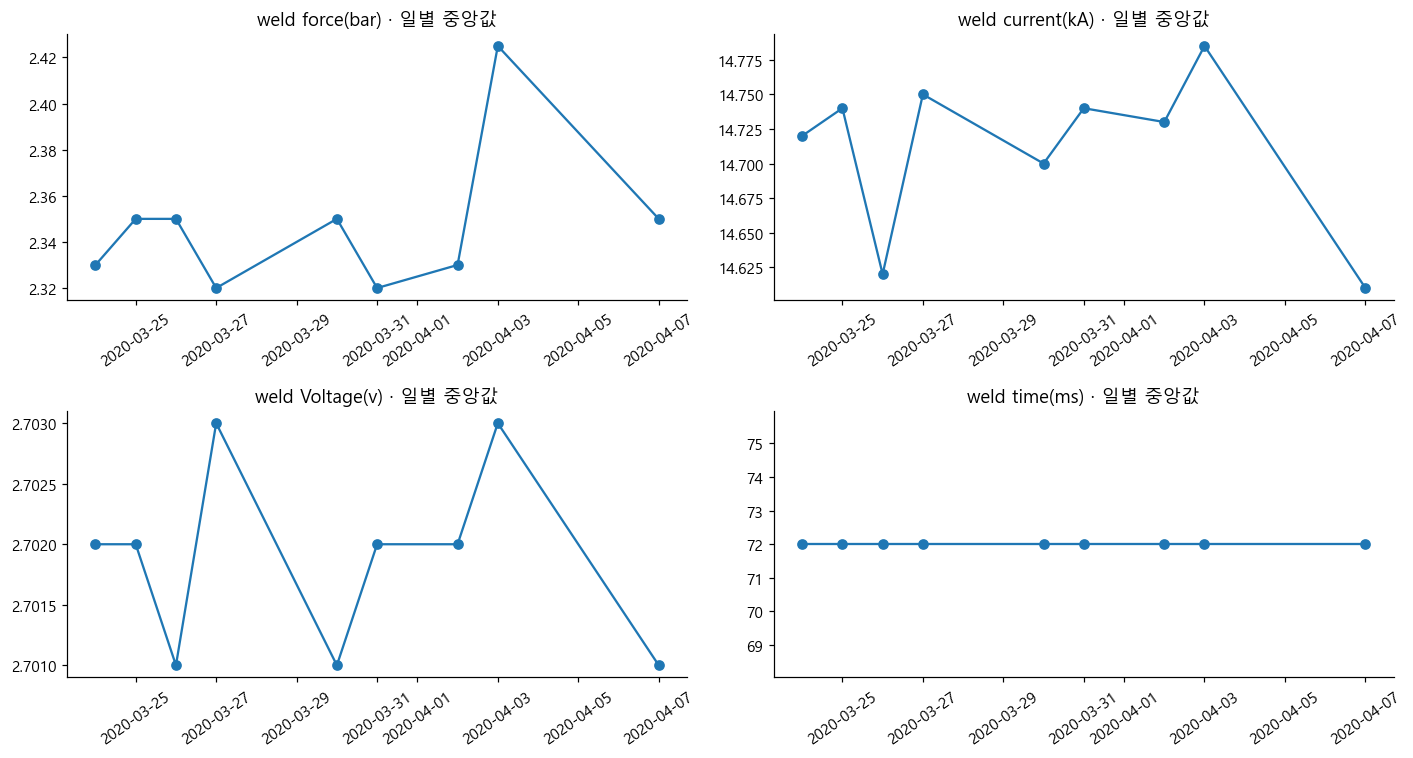

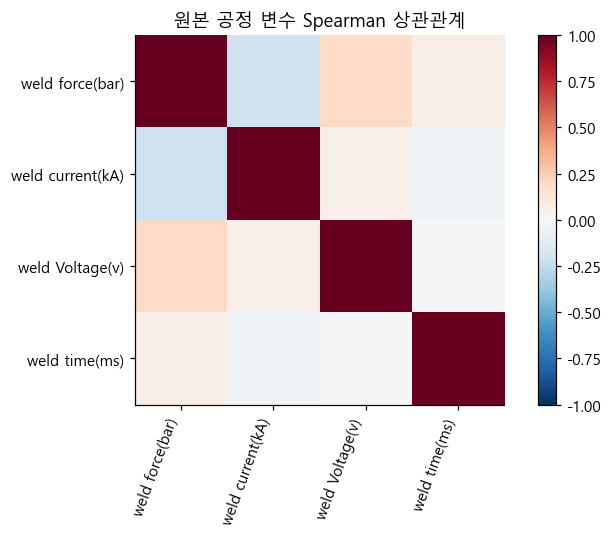

In [5]:
keys=['Machine_Name','Item No','working time']
display(raw.groupby(keys).size().rename('records').to_frame())
daily=raw.groupby('working time')[process].median()
fig,axes=plt.subplots(2,2,figsize=(13,7))
for ax,c in zip(axes.flat,process):
    ax.plot(daily.index,daily[c],marker='o');ax.set_title(c+' · 일별 중앙값');ax.tick_params(axis='x',rotation=35)
plt.tight_layout();plt.show()
corr_plot(raw,process,'원본 공정 변수 Spearman 상관관계')

## 5. 불량 집계의 결합 가능성
`result`는 날짜·설비·품목별로 불량 유형이 반복되는 구조입니다. `defect`를 불량 건수로 해석한 **가설적 집계**만 보여 줍니다. 개별 행 라벨이나 불량률로 변환하지 않습니다. 결과가 없는 날짜는 0건으로 채우지 않습니다.

,idx,Machine_Name,Item No,working time,defect,defect type,Unnamed: 6
0,1,Spot-01,65235-25800,2020-03-24,2,1,파임불량
1,2,Spot-01,65235-25800,2020-03-24,1,2,용접부족
2,3,Spot-01,65235-25800,2020-03-24,1,3,크랙발생
3,4,Spot-01,65235-25800,2020-03-25,3,1,NaN
4,5,Spot-01,65235-25800,2020-03-25,2,2,NaN
5,6,Spot-01,65235-25800,2020-03-25,3,3,NaN
6,7,Spot-01,65235-25800,2020-03-26,3,1,NaN
7,8,Spot-01,65235-25800,2020-03-26,2,2,NaN
8,9,Spot-01,65235-25800,2020-03-26,2,3,NaN
9,10,Spot-01,65235-25800,2020-03-30,1,1,NaN


process_records  result_rows  \
Machine_Name Item No     working time                                 
Spot-01      65235-25800 2020-03-24               1200          3.0   
                         2020-03-25               1352          3.0   
                         2020-03-26               1000          3.0   
                         2020-03-27               1648          NaN   
                         2020-03-30               1470          3.0   
                         2020-03-31               1800          2.0   
                         2020-04-02               2000          3.0   
                         2020-04-03                800          3.0   
                         2020-04-07                669          3.0   

                                       reported_defect_sum  
Machine_Name Item No     working time                       
Spot-01      65235-25800 2020-03-24                    4.0  
                         2020-03-25                    8.0  
                         2020-03-26                    7.0  
                         2020-03-27                    NaN  
                         2020-03-30                    4.0  
                         2020-03-31                    5.0  
                         2020-04-02                    4.0  
                         2020-04-03                    4.0  
                         2020-04-07                    3.0

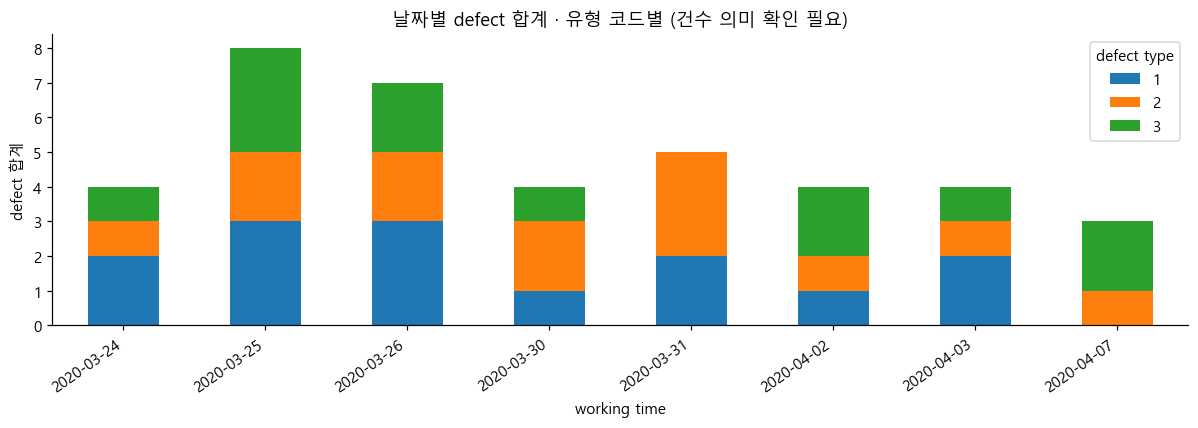

원본 관측 날짜: 9 결과 관측 날짜: 8
결과 미제공 그룹: 1


In [6]:
display(result)
coverage=raw.groupby(keys).size().rename('process_records').to_frame().join(
    result.groupby(keys).agg(result_rows=('defect','size'), reported_defect_sum=('defect','sum')),how='outer')
display(coverage)
daily_defect=result.pivot_table(index='working time',columns='defect type',values='defect',aggfunc='sum')
fig,ax=plt.subplots(figsize=(11,4));daily_defect.plot.bar(stacked=True,ax=ax,rot=35)
ax.set_xticklabels(daily_defect.index.strftime('%Y-%m-%d'),rotation=35,ha='right')
ax.set_title('날짜별 defect 합계 · 유형 코드별 (건수 의미 확인 필요)');ax.set_ylabel('defect 합계')
plt.tight_layout();plt.show()
print('원본 관측 날짜:',raw['working time'].nunique(),'결과 관측 날짜:',result['working time'].nunique())
print('결과 미제공 그룹:',int(coverage.result_rows.isna().sum()))

## 6. 주제 선정 해석
- 원본 11,939행은 결측과 문서상 수집 범위 이탈이 없습니다. 반면 scaled CSV에는 열별 15~23개 결측이 있고, 원본 min-max 변환과 값 분포도 일치하지 않습니다. 같은 행 수라는 이유만으로 동일 기록이라고 결합하면 안 됩니다.
- 설비와 품목이 각각 하나이고 소재 두께도 상수입니다. 관측은 9일에 한정되며 불량 결과가 없는 날짜가 1일 있습니다.
- 공정 조건 이상 탐지는 검토할 수 있지만, 범위 이탈을 실제 불량으로 취급하면 안 됩니다.
- 개별 용접 품질 분류에는 각 생산순번에 연결된 정답이 추가로 필요합니다. 날짜별 불량 값을 모든 생산 행에 복제하면 잘못된 라벨이 됩니다.
- 일별 불량 집계 예측은 관측 일수가 적어 검증 근거가 약합니다. 기록이 없는 날짜와 0건을 구별해야 합니다.
- 극단값 때문에 min-max 스케일링이 정상 영역을 압축할 수 있습니다. 전처리는 학습 구간 안에서 추정합니다.
- 날짜 단위 분할을 검토하고 설비·품목이 추가로 확보되는지 확인합니다.

## 추가 EDA · PCA로 데이터 구조 비교

**계획:** 참조 데이터와 입력 변수를 명시하고 → 설명 분산과 PC1·PC2 → 주성분 계수 → T²·SPE 및 변수별 잔차를 확인합니다.

이 분석은 **탐색용**입니다. 학습·검증·테스트 성능을 산출하지 않습니다. 참조 데이터에서 중앙값 대체, 상수 열 제거, 표준화와 PCA를 학습하고 비교 대상에 적용합니다. ID·라벨·날짜 코드는 입력에서 제외합니다. 설명 분산은 참조 집합 기준이며, 산점도만 그룹별 최대 1,800행으로 제한하고 통계는 전체 행으로 계산합니다.

95% 설명에 필요한 성분 수와 별개로, SPE 계산은 **유효 순위보다 최소 1개 적은 성분**을 유지합니다. 따라서 유지 분산이 95% 미만일 수 있습니다. 모든 성분을 유지해 잔차가 0이 되는 것을 피하기 위한 EDA 설정이며 최적 성분 수는 아닙니다. T²는 유지한 축에서의 거리, SPE는 버린 축의 잔차 제곱합입니다. 두 지표는 확률도, 이상 정답도 아닙니다.

주성분 계수는 단위 고유벡터의 가중치이며 인과적 중요도가 아닙니다. 주성분 부호는 임의입니다. 주제 간 T²·SPE 절댓값이나 설명 분산으로 모델 성능 순위를 매기지 않습니다.

In [7]:
import sys, json
sys.path.insert(0,str(ROOT / 'src'))
from pca_eda import fit_pca, diagnostics, summary
PCA_OUTPUT=ROOT / 'outputs' / 'pca'
PCA_OUTPUT.mkdir(parents=True,exist_ok=True)
pca_summaries=[]

### 용접기 적용 기준
Excel 원본의 가압력·전류·전압·통전시간 4개만 사용합니다. scaled CSV는 원본과 대응이 확인되지 않아 함께 학습하지 않습니다. 작업 날짜를 색으로 구분하며, 날짜별 불량 집계를 개별 생산 기록의 라벨로 사용하지 않습니다.

용접기 · 원본 공정 변수 4개
제외 변수: [] / 평가 데이터 중앙값 대체 셀: 0
95% 설명 성분 수: 4 / 재구성·T² 계산 성분 수: 3 / 유효 순위: 4


,PC,variance_pct,cumulative_pct
0,1,37.096566,37.096566
1,2,25.085526,62.182092
2,3,23.117441,85.299533
3,4,14.700467,100.000000


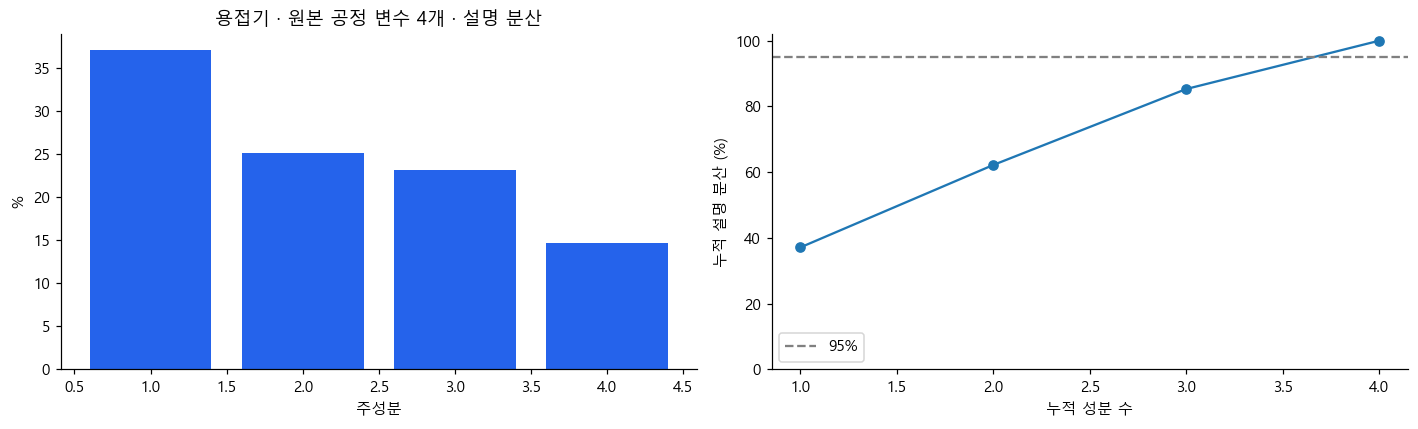

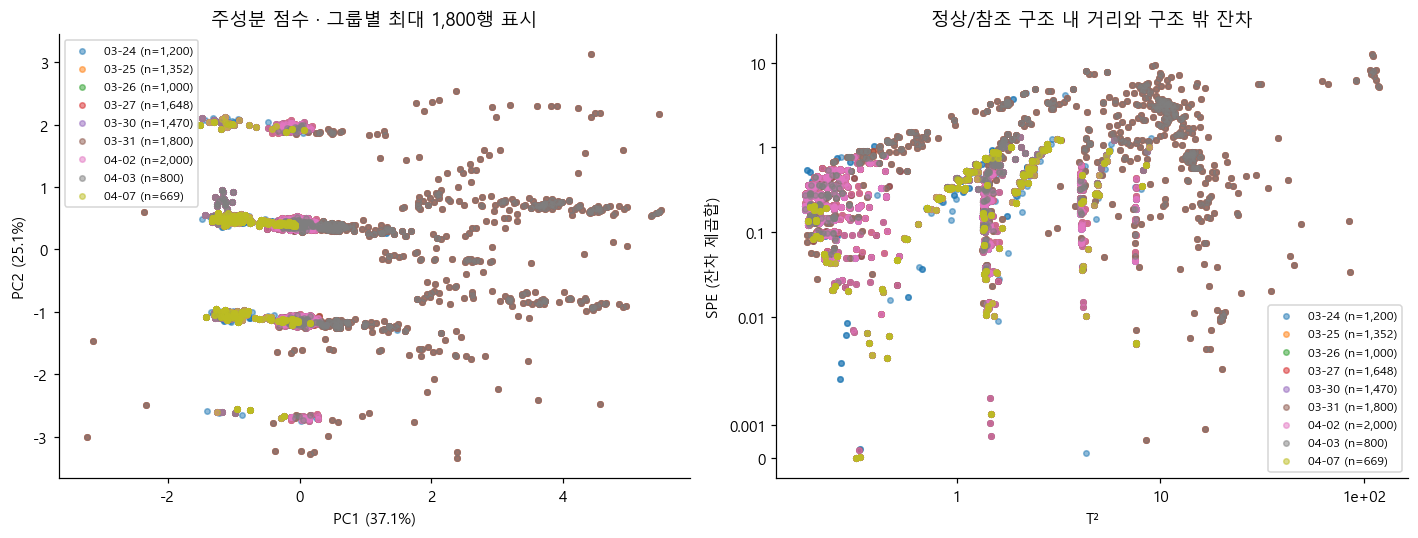

,rows,T2_median,SPE_median,SPE_p95
group,,,,
03-24,1200,1.157662,0.256879,0.857958
03-25,1352,1.408031,0.408832,3.775851
03-26,1000,1.274322,0.285148,0.877708
03-27,1648,1.365384,0.328127,3.477963
03-30,1470,1.218173,0.210337,0.866985
03-31,1800,1.359652,0.304994,3.384237
04-02,2000,1.113020,0.211443,0.751019
04-03,800,2.131691,0.688265,5.251817
04-07,669,1.359307,0.254915,0.959653


,PC1,PC2
주성분 계수 (단위 고유벡터),,
weld force(bar),0.660366,-0.016149
weld current(kA),0.659142,-0.054463
weld Voltage(v),0.358654,0.207602
weld time(ms),-0.028564,0.976563


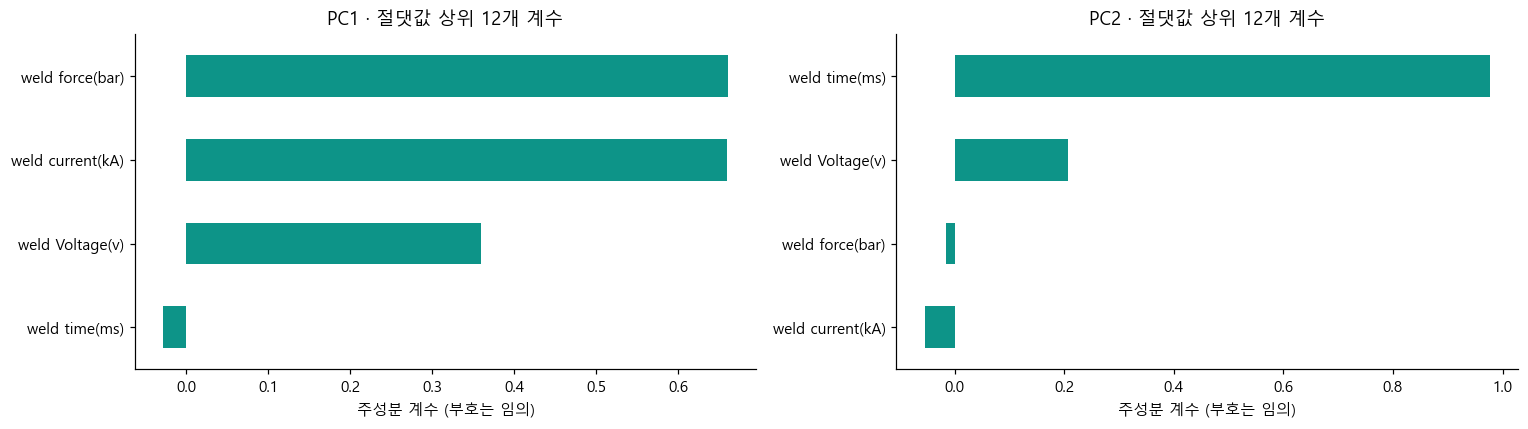

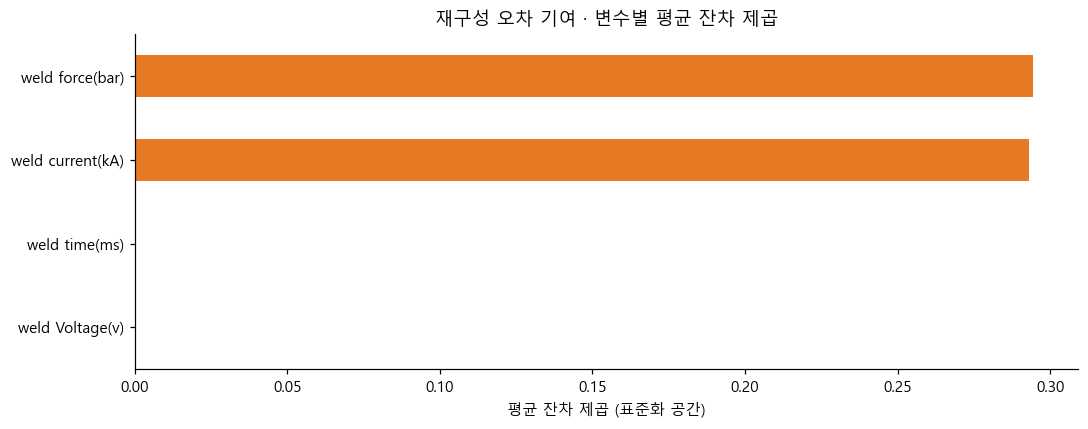

,idx,working time,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),SPE,T2
10877,408,2020-04-03,10.54,14.75,2.476,72.0,12.570998,109.466229
4691,1142,2020-03-27,10.54,14.75,2.476,72.0,12.570998,109.466229
7801,1132,2020-03-31,10.54,14.75,2.476,72.0,12.570998,109.466229
1877,678,2020-03-25,10.54,14.75,2.476,72.0,12.570998,109.466229
10878,409,2020-04-03,10.54,14.76,2.476,72.0,12.070289,110.076701
7802,1133,2020-03-31,10.54,14.76,2.476,72.0,12.070289,110.076701
1878,679,2020-03-25,10.54,14.76,2.476,72.0,12.070289,110.076701
4692,1143,2020-03-27,10.54,14.76,2.476,72.0,12.070289,110.076701
4854,1305,2020-03-27,9.27,14.72,2.747,72.0,9.386628,9.397847
2040,841,2020-03-25,9.27,14.72,2.747,72.0,9.386628,9.397847


In [8]:
pca_result=fit_pca(raw[process])
date_groups=pd.to_datetime(raw['working time']).dt.strftime('%m-%d')
diagnostics(pca_result,date_groups,'용접기 · 원본 공정 변수 4개')
pca_summaries.append(summary(pca_result,'02 용접기','원본 전체 행; 작업 날짜별 투영'))
top=np.argsort(pca_result['spe'])[-10:][::-1]
display(raw.iloc[top][['idx','working time',*process]].assign(SPE=pca_result['spe'][top],T2=pca_result['t2'][top]))

**해석:** 날짜별로 다른 위치에 모이거나 재구성 오차가 높은 기록은 공정조건 변화 후보입니다. 불량 정답이 아니므로 이를 이용해 F1-score를 계산할 수 없습니다. 생산순번은 상위 오차 기록을 찾는 용도로만 표시합니다.

In [9]:
(PCA_OUTPUT / 'topic02.json').write_text(json.dumps(pca_summaries,ensure_ascii=False,indent=2),encoding='utf-8')
display(pd.DataFrame(pca_summaries))

,analysis,reference,reference_rows,evaluation_rows,features,rank,PC1_PC2_variance_pct,components_for_95pct,residual_components,residual_model_variance_pct
0,02 용접기,원본 전체 행; 작업 날짜별 투영,11939,11939,4,4,62.182092,4,3,85.299533
